In [2]:
import sidechainnet as scn
import torch
from torch.utils.data import DataLoader
import numpy as np
import requests
import textwrap
from IPython.display import display, HTML, display
import torch.nn as nn
import torch.nn.functional as F
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import layers
import matplotlib.pyplot as plt
import json


/home/myoung/csc6621_final_project/.venv/lib/python3.12/site-packages/sidechainnet/structure/build_info.py:225: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
%matplotlib inline

In [3]:
# Uncomment the line below to install the required dependencies for this project. Make sure to run this in a Python environment where you have permissions to install packages.
# if you using uv place uv after the ! in the line below, otherwise use pip

#!pip install -r requirements.txt

In [4]:
np.random.seed(42)
torch.manual_seed(42)

proteins_data = scn.load(casp_version=12, casp_thinning=30, scn_dir="./data/")
proteins_dataloaders = scn.load(casp_version=12, casp_thinning=30, scn_dir="./data/", with_pytorch="dataloaders")


SidechainNet was loaded from ./data/sidechainnet_casp12_30.pkl.
SidechainNet was loaded from ./data/sidechainnet_casp12_30.pkl.


In [5]:

print(type(proteins_data))

#dictionary of dataloaders for train, val, and test sets
print(type(proteins_dataloaders))

<class 'sidechainnet.dataloaders.SCNDataset.SCNDataset'>
<class 'dict'>


In [6]:
# validation loaders for different sequence identity thresholds
# valid-10: 10% sequence identity threshold, no protein in the validation set has more than 10% sequence identity to any protein in the training set
# valid-90: 90% sequence identity threshold, no protein in the validation set has more than 90% sequence identity to any protein in the training set
# valid-10 is the most challenging validation set (least similar to the training set) 
# valid-90 is the least challenging one (similar to the training set)

proteins_dataloaders.keys()

dict_keys(['train', 'train-eval', 'test', 'valid-10', 'valid-20', 'valid-30', 'valid-40', 'valid-50', 'valid-70', 'valid-90'])

In [7]:
train_dataloader = proteins_dataloaders['train']


val_dataloader = proteins_dataloaders['valid-30']

test_dataloader = proteins_dataloaders['test']

In [8]:
# input variables for each protein in the dataset
# seqs: amino acid sequence of the protein
# seqs_onehot: one-hot encoded representation of the amino acid sequence, where each amino acid is represented as a binary vector indicating its presence at each position in the sequence
# seqs_int: integer encoded representation of the amino acid sequence, where each amino acid is represented as an integer index corresponding to its position in a predefined amino acid alphabet
# evolutionary: evolutionary information (position-specific scoring matrix) for the protein sequence, describes how each position in the sequence is conserved across different species
# masks: used to pad the sequences to a fixed length since sequences can have varying lengths, indicates which positions in the sequence are valid (1) and which are padding (0)

# target variables for each protein in the dataset
# angles: 3D coordinates of the protein backbone and sidechain atoms
# coords: 3D coordinates of the protein backbone atoms (N, CA, C)
# secondary: secondary structure information for the protein sequence


# metadata variables for each protein in the dataset
# ids: unique identifier for the protein from the Protein Data Bank (PDB)
# resolution: resolution of the protein structure (in Angstroms), lower means higher quality structure
# unmodified_seq: unmodified sequence of the protein (original sequence without any modifications or padding)

batch = next(iter(train_dataloader))

# List all attributes that don't start with an underscore
columns = [attr for attr in dir(batch) if not attr.startswith('_')]
print(columns)

['angles', 'coords', 'copy', 'cpu', 'cuda', 'device', 'evolutionary', 'fillna', 'ids', 'is_modified', 'masks', 'max_len', 'pad_for_batch', 'proteins', 'pssm', 'resolution', 'resolutions', 'secondary', 'seconday_structure', 'seqs', 'seqs_int', 'seqs_onehot', 'set_device', 'torch', 'trim_ends', 'unmodified_seq', 'unmodified_seqs']


In [9]:
input_variables = ['seqs', 'seqs_onehot', 'seqs_int', 'evolutionary', 'masks']
target_variables = ['angles', 'coords', 'secondary']

In [10]:
# shape of input variables

for var in input_variables:
    print(f"{var}: {getattr(batch, var).shape}")

seqs: torch.Size([32, 93, 20])
seqs_onehot: torch.Size([32, 93, 20])
seqs_int: torch.Size([32, 93])
evolutionary: torch.Size([32, 93, 21])
masks: torch.Size([32, 93])


In [11]:
#shape of output variables

for var in target_variables:
    print(f"{var}: {getattr(batch, var).shape}")

angles: torch.Size([32, 93, 12])
coords: torch.Size([32, 93, 15, 3])
secondary: torch.Size([32, 93, 8])


In [12]:
def get_protein_name_from_pdb(protein) -> str:
    # 1. Extract the PDB ID from the protein's metadata
    # 

    pdb_id = protein.id.split('_')[0]
        
    print(pdb_id)

    # 2. Ping the official Protein Data Bank API to get the biological name
    try:
        url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_id}"
        response = requests.get(url)
        response.raise_for_status() # Check for HTTP errors
        
        # Extract the title from the JSON payload
        actual_protein_name = response.json()['struct']['title']
        
        format_protein_name = textwrap.fill(actual_protein_name, width=30)
        
        
        
    except Exception as e:
        print(f"Could not fetch name from PDB API: {e}")
        format_protein_name = protein.id
        
    return format_protein_name
    

In [13]:
def view_protein_name_from_pdb(proteins_data, index: int):

    protein = proteins_data[index]
    protein.fastbuild(inplace=True)
    protein_name = get_protein_name_from_pdb(protein)
        
    protein_view = protein.to_3Dmol()
    
    view_html = protein_view._make_html()

    display(HTML(f"""
    <div style="position:relative; display:inline-block; line-height:0;">
    <div style="position:absolute; top:10px; left:50%; transform:translateX(-50%);
                background:rgba(0,0,0,0.65); color:white; padding:5px 14px;
                border-radius:4px; font-size:14px; font-weight:bold;
                white-space:nowrap; z-index:999; line-height:normal;">
        Protein: {protein_name}
    </div>
    {view_html}
    </div>
"""))

In [14]:
# Views the name of the protein from the PDB API for the 4th protein in the dataset (index=3)

view_protein_name_from_pdb(proteins_data, index=500)

2MV7


In [15]:
# Finds the first 20 proteins in the dataset that contain both helix (H) and sheet (E) secondary structure elements, and prints their IDs.

def get_dataset_ids(dataset):
    if hasattr(dataset, "ids"):
        return list(dataset.ids)
    elif hasattr(dataset, "proteins"):
        return list(dataset.proteins.keys())
    else:
        ids = []
        for p in dataset:
            if hasattr(p, "id"):
                ids.append(p.id)
        return ids

ids = get_dataset_ids(proteins_data)
print("Total proteins:", len(ids))

hits = []
hit_ids = []
for pid in ids:
    try:
        p = proteins_data[pid]
        ss = getattr(p, "secondary_structure", None)
        if ss and ("H" in ss) and ("E" in ss):
            hits.append(pid)
            if len(hits) >= 20:
                break
    except Exception:
        pass

print("Proteins with both helix and sheet:")
for h in hits:
    print(h)

Total proteins: 25044
Proteins with both helix and sheet:
1RDQ_2_I
2XAP_2_D
2OJ6_d2oj6c1
3N00_2_B
4R8T_1_A
1OQD_d1oqdn-
1G0Y_2_I
3R7G_2_B
1XOF_2_B
4EXT_2_B
1JLZ_1_A
2FHW_2_A
6RLX_1_A
2YT9_d2yt9a2
1AVF_1_P
2DLQ_d2dlqa1
3C66_2_C
2DRP_d2drpd2
2KVG_1_A
4F02_3_C


In [16]:
# The coloring from purple to red describes the start and end of the polypeptide chain
# Purple is the N-terminus (start) and red is the C-terminus (end)
# alpha-helix can be seen in the purple regions (cicular helix) and beta-sheet (flat) can be seen in the red regions
# change the index to view different proteins from the dataset
# Grey objects protruding from the protein are sidechains
# Red ends of sidechains are oxygen atoms, blue ends are nitrogen atoms, and grey ends are carbon atoms
# Messenger RNA (mRNA) creates proteins by translating DNA sequences into amino acid sequences, which then fold into 3D structures to form functional proteins
# mRNA starts at the N-terminus (purple)(-NH2) and ends at the C-terminus (red)(COOH)

view_protein_name_from_pdb(proteins_data, index=hits[0])

1RDQ


In [17]:
# Repating the shapes of the input and target variables for the first protein in the dataset (index=0)

for var in input_variables:
    print(f"{var}: {getattr(batch, var).shape}")
print ("====" * 10)
for var in target_variables:
    print(f"{var}: {getattr(batch, var).shape}")

seqs: torch.Size([32, 93, 20])
seqs_onehot: torch.Size([32, 93, 20])
seqs_int: torch.Size([32, 93])
evolutionary: torch.Size([32, 93, 21])
masks: torch.Size([32, 93])
angles: torch.Size([32, 93, 12])
coords: torch.Size([32, 93, 15, 3])
secondary: torch.Size([32, 93, 8])


In [18]:
# Helper class to wrap the PyTorch DataLoader from sidechainnet into a Keras-compatible dataset

class SCNDataLoader(keras.utils.PyDataset):
    """Wraps a sidechainnet DataLoader to yield (seqs_int, angles) batches for Keras."""
    def __init__(self, scn_loader, **kwargs):
        super().__init__(**kwargs)
        self._batches = list(scn_loader)

    def __len__(self):
        return len(self._batches)

    def __getitem__(self, idx):
        b = self._batches[idx]
        angles = torch.nan_to_num(b.angles, nan=0.0)
        return b.seqs_int, angles

train_dl = SCNDataLoader(train_dataloader)
val_dl = SCNDataLoader(val_dataloader)

### Input Batch
- 32 data points
- 102 Features (length of a protein padded to 102, since proteins can have variable length residues, which are the name of amino-acids in a protein chain)
    - Integer-encoded (The Embedding layer of the BiLSTM turns this into a 128-D dense vector)

### Output Batch
- 32 data points (see above)
- 102 Features (see above)
- 12 outputs (backbone/sidechain angles per residue)

### 12 Ouputs

#### Backbone Angles (3)
| Index | Angle | Description |
|-------|-------|-------------
| 0 | $\phi$ (phi) | Rotation around $\ N-C\alpha$ bond |
| 1 | $\psi$ (psi) | Roation around $\ C\alpha-C$ bond |
| 2 | $\omega$ (omega) | Rotation around C-N peptide bond (usually $180\degree$) |

<br />

#### Sidechain angles (6)

|Index | Angle | Description |
|------|-------|-------------|
| 3 | $\chi^1$ | First sidechain torsion from $C\alpha$ |
| 4 | $\chi^2$ | Second sidechain torsion from |
| 5 - 8 | $\chi^3 - \chi^6$ | Further sidechain rotations (used by large amino acids) |

<br />

#### Backbone bond angles (3):
| Index | Angle | Description |
|-------|-------|-------------|
| 9 | $N-C\alpha-C$ | Bond angle at $C\alpha$ |
| 10 | $C\alpha-C-N$ | Bond angle at carbonyl carbon |
| 11 | $C-N-C\alpha$ | Bond angle at nitrogen |

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
model = keras.Sequential([
    keras.Input(shape=(None,)),
    layers.Embedding(input_dim=21, output_dim=128, mask_zero=True),  # 20 amino acids + 1 for padding
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Dense(128, activation='relu'),
    layers.TimeDistributed(layers.Dense(12, activation='tanh'))  # Predicting 3 angles per residue
])

model.to(device)


<Sequential name=sequential, built=True>

In [40]:
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

In [ ]:
history = model.fit(
    train_dl,
    validation_data=val_dl,
    epochs=10
)

Epoch 1/10
  2/787 ━━━━━━━━━━━━━━━━━━━━ 22:30 2s/step - loss: 2.6686 - mse: 2.6681

In [ ]:
# save the training history and model weights to files specified by the user

file_name = input("Enter the file name to save the training history (without extension): ")
history_path = f'{file_name}.json'
with open(history_path, 'w') as f:
    json.dump(history.history, f)

model.save(f'{file_name}.keras')

In [ ]:
# function to plot the training and validation accuracy and loss curves from a trained Keras model history object with an optional title parameter for the plot

def plot_accuracy_loss(history, title="Accuracy/Loss Plots"):
    plt.figure(figsize=(12, 5))
    plt.suptitle(title, fontsize=16)
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(history.history['mse'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_mse'], label='Validation Accuracy', linewidth=2)
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

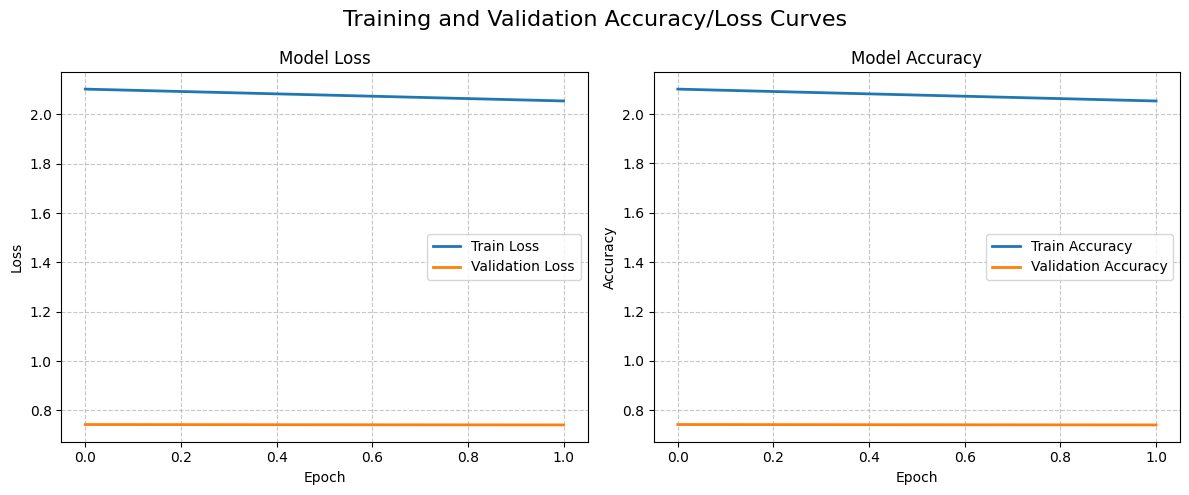

In [ ]:
plot_accuracy_loss(history, title="Training and Validation Accuracy/Loss Curves")

In [2]:
def BiLSTMModel(embedding_dim=64, lstm_units=64, dense_units=128, optim="adam", loss="mse", metrics=["mse"]):
    model = keras.Sequential([
        keras.Input(shape=(None,)),
        layers.Embedding(input_dim=21, output_dim=embedding_dim, mask_zero=True),
        layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True)),
        layers.Dense(dense_units, activation='relu'),
        layers.TimeDistributed(layers.Dense(12, activation='tanh'))  # Predicting 3 angles per residue, use tanh to constrain angles between -1 and 1
    ])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return model.to(device)

### Looking for a good embedding size to increase training speed

In [4]:
np.random.seed(42)
torch.manual_seed(42)
train_dataloader_64 = scn.load(casp_version=12, casp_thinning=30, scn_dir="./data/", with_pytorch="dataloaders", num_workers=2, batch_size=64)

SidechainNet was loaded from ./data/sidechainnet_casp12_30.pkl.


In [ ]:
def protin_gen(t)

In [28]:
embedding_dim_8 = BiLSTMModel(embedding_dim=8, lstm_units=64, dense_units=128, optim="adam", loss="mse", metrics=["mse"])

In [34]:
embedding_dim_8.compile(optimizer='adam', loss='mse', metrics=['mse'])

history = embedding_dim_8.fit(
    train_dl,
    validation_data=val_dl,
    learning_rate=0.001,
    epochs=4
)

Epoch 1/4
181/787 ━━━━━━━━━━━━━━━━━━━━ 35:27 4s/step - loss: 2.1491 - mse: 2.1466

KeyboardInterrupt: 